In [1]:
import sys
from pathlib import Path

# path to the directory that contains your package
sys.path.append(str(Path("../../src")))

In [2]:
from iarena.gaming.goldmine import GoldMineConfiguration

manual_map = [
    [0.0, 2.0, 3.0],
    [4.0, 1.5, 2.5],
    [3.5, 2.0, 1.0],
]

configuration = GoldMineConfiguration(
    start=(0, 0),               # Starting position (row, col). By default, top-left corner
    target=(2, 2),              # Target position (row, col)
    map_data=manual_map,        # Matrix defining the map costs
)

print(f"Configuration created successfully {configuration}")


Configuration created successfully <iarena.gaming.goldmine.GoldMineConfiguration.GoldMineConfiguration object at 0x7711a43ab890>


In [3]:
from iarena.gaming.goldmine import GoldMineConfiguration

random_configuration = GoldMineConfiguration(
    n_rows=4,
    n_cols=4,
    start=(0, 0),
    map_generator="uniform",
    seed=0,
)

print(f"Configuration with random map created successfully {random_configuration}")


Configuration with random map created successfully <iarena.gaming.goldmine.GoldMineConfiguration.GoldMineConfiguration object at 0x7711dc2361b0>


In [4]:
from iarena.gaming.goldmine import GoldMineRules

rules = GoldMineRules(configuration)

print("Rules created successfully")
print(f" - Test rules: Number of players: {rules.n_players()}")


Rules created successfully
 - Test rules: Number of players: 1


/tmp/ipykernel_14457/1173321520.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rules._generate_plot_position(rules.first_position()).show()


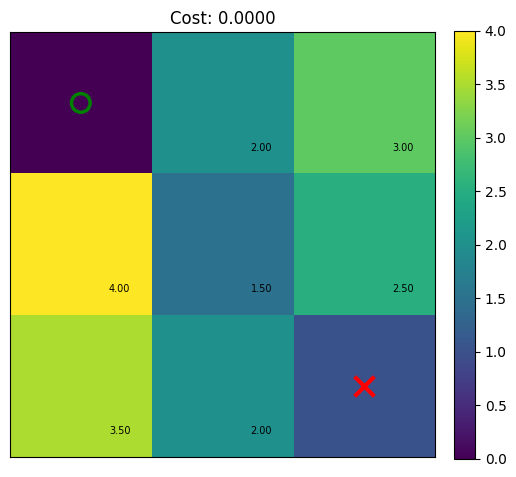

In [5]:
rules._generate_plot_position(rules.first_position()).show()


In [6]:
from iarena.gaming.goldmine import GoldMinePosition

first_position = rules.first_position()

print("Initial position created")
print(f"Current accumulated cost: {first_position.get_current_cost()}")

valid_directions = list(first_position.get_valid_directions())
print(f"Valid directions: {valid_directions}")

print("Directions with costs:")
for direction, cost in first_position.get_directions_with_cost():
    print(f"  - {direction}: {cost}")


Initial position created
Current accumulated cost: 0.0
Valid directions: [<SquareMapDirection.RIGHT: (0, 1)>, <SquareMapDirection.DOWN: (1, 0)>]
Directions with costs:
  - SquareMapDirection.RIGHT: 2.0
  - SquareMapDirection.DOWN: 4.0


Movement created: <Move RIGHT>
Is the movement legal? False
Second position created successfully after applying movement <Move RIGHT>


/tmp/ipykernel_14457/1513414669.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rules._generate_plot_position(second_position).show()


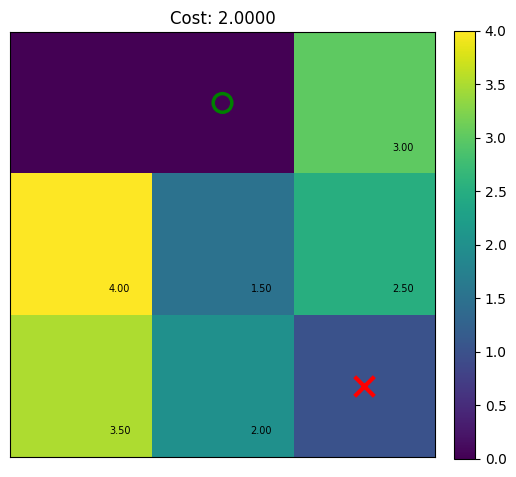

In [7]:
from iarena.gaming.goldmine import GoldMineMovement
from iarena.utilizing.mapping.square_map.SquareMapDirection import SquareMapDirection

move = GoldMineMovement(direction=SquareMapDirection.RIGHT)
print(f"Movement created: {move}")

is_legal = move in rules.possible_movements(first_position)
print(f"Is the movement legal? {is_legal}")

second_position = rules.next_position(first_position, move)
print(f"Second position created successfully after applying movement {move}")
rules._generate_plot_position(second_position).show()


In [8]:
from iarena.playing import Player

class AlwaysRightGoldMinePlayer(Player):

    def name(self) -> str:
        return "always-right"

    def play(self, position: GoldMinePosition) -> GoldMineMovement:
        possible_movements = position.get_directions_with_cost()

        for direction, cost in possible_movements:
            if direction == SquareMapDirection.RIGHT:
                print(f"[{self.name()}] Choosing RIGHT")
                return GoldMineMovement(direction)

        fallback = possible_movements[0].direction
        print(f"[{self.name()}] RIGHT not available, choosing {fallback}")
        return GoldMineMovement(direction=fallback)

player = AlwaysRightGoldMinePlayer()
print(f"Player created successfully: {player.name()}")


Player created successfully: always-right


In [9]:
print(f"Testing player {player.name()} in the first position")
movement_chosen = player.play(first_position)
print(f"Player chose movement: {movement_chosen.direction}")


Testing player always-right in the first position
[always-right] Choosing RIGHT
Player chose movement: SquareMapDirection.RIGHT


In [10]:
from iarena.arening import ArenaFactory

arena = ArenaFactory.create_arena(
    rules=rules,        # Game rules
    players=[player],   # List of players (in this case, only one)
    max_turns=20,       # Maximum number of turns to prevent infinite loops
)

# Run the game and get the final scoreboard
scoreboard = arena.play(rules=rules, players=players)

print("Game finished")
print(f"Final score: {scoreboard.get_score(0)}")


NameError: name 'players' is not defined

In [ ]:
from iarena.gaming.goldmine.GoldMineTerminalView import GoldMineTerminalView

arena = ArenaFactory.create_arena(
    rules=rules,        # Game rules
    players=[player],   # List of players (in this case, only one)
    max_turns=20,       # Maximum number of turns to prevent infinite loops
    view=GoldMineTerminalView()
)

# Run the game and get the final scoreboard
scoreboard = arena.play(rules=rules, players=players)
print(f"Final score: {scoreboard.get_score(0)}")


In [ ]:
from iarena.playing import PolyvalentTerminalPlayer

human_player = PolyvalentTerminalPlayer("human")

arena = ArenaFactory.create_arena(
    rules=rules,        # Game rules
    players=[human_player],   # List of players (in this case, only one)
    max_turns=20,       # Maximum number of turns to prevent infinite loops
    view=GoldMineTerminalView()
)

# Run the game and get the final scoreboard
scoreboard = arena.play(rules=rules, players=[human_player])
print(f"Final score: {scoreboard.get_score(0)}")


In [ ]:
class MemoryGoldMinePlayer(Player):

    def __init__(self, name: str):
        super().__init__(name)
        self.steps = 0

    def starting_game(self, rules: Rules, player_index: PlayerIndex) -> None:
        self.steps = 0

    def play(self, rules, position):
        # Update the number of steps
        self.steps += 1

        # Select next movement
        ...
        # return movement


In [ ]:
# Create a configuration with the compass activated
configuration_with_compass = GoldMineConfiguration(
    n_rows=4,
    n_cols=4,
    start=(0, 0),
    target=(3, 3),
    map_generator="uniform",
    seed=0,
    compass_activated=True,
)
rules_with_compass = GoldMineRules(configuration_with_compass)
print(f"Compass activated: {rules_with_compass.compass_activated()}")

# Get the first position and check the compass hint
first_position_with_compass = rules_with_compass.first_position()
compass_hint = first_position_with_compass.get_compass_hint()
print(f"Compass hint: {compass_hint}")


In [ ]:
# Create a configuration with the proximity hint activated
configuration_with_proximity = GoldMineConfiguration(
    n_rows=4,
    n_cols=4,
    start=(0, 0),
    target=(3, 3),
    map_generator="uniform",
    seed=0,
    proximity_activated=True,
)
rules_with_proximity = GoldMineRules(configuration_with_proximity)
print(f"Proximity hint activated: {rules_with_proximity.proximity_activated()}")

# Get the first position and check the proximity hint
first_position_with_proximity = rules_with_proximity.first_position()
proximity_hint = first_position_with_proximity.get_proximity_hint()
print(f"Proximity hint: {proximity_hint}")
